In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [124]:
df = pd.read_csv('housin1.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [125]:
df.shape


(20640, 10)

In [126]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [127]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [128]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [130]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

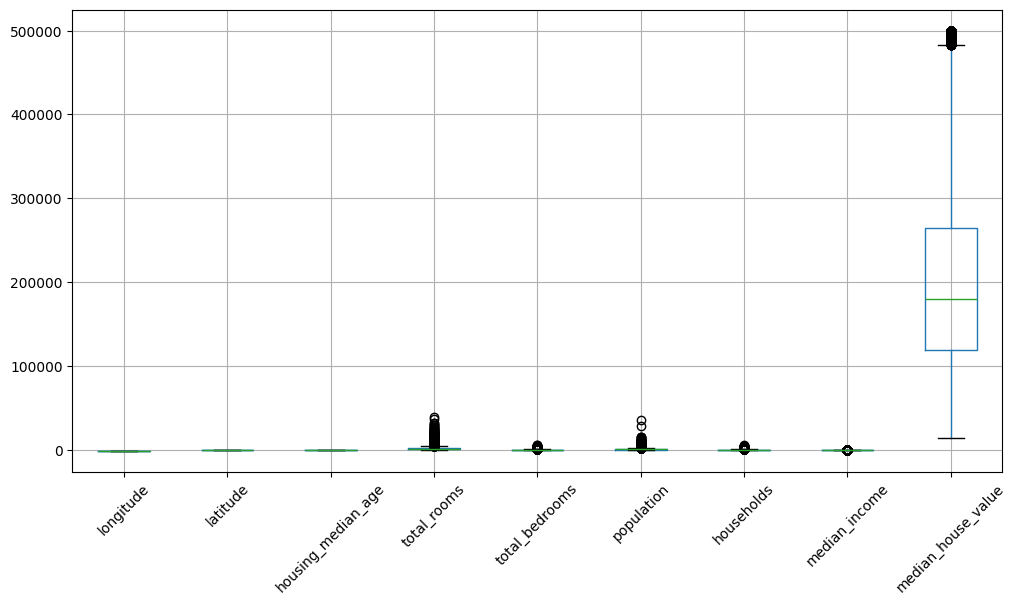

In [131]:
df.boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

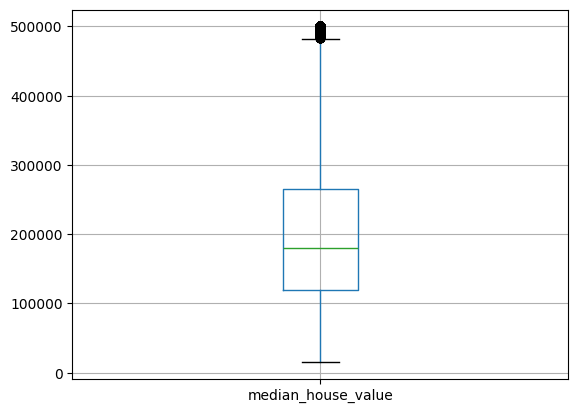

In [132]:
df.boxplot(column='median_house_value')
plt.show()

In [133]:
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,True,False,False,False
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,True,False,False,False
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,True,False,False,False
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,True,False,False,False


In [137]:
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

for col in df.select_dtypes(include=np.number).columns:
    df = remove_outliers(df, col)

In [138]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [139]:
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,False,False,True,False
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,False,False,True,False
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,True,False,False,False
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,True,False,False,False
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,True,False,False,False
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,True,False,False,False


In [141]:
y

2        352100.0
3        341300.0
4        342200.0
5        269700.0
6        299200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 15923, dtype: float64

In [142]:
X = X.values
y = y.values

In [143]:
X = pd.DataFrame(X)

In [144]:
X

,0,1,2,3,4,5,6,7,8,9,10,11
0,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,False,False,True,False
1,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,False,False,True,False
2,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,False,False,True,False
3,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,False,False,True,False
4,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
15918,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,True,False,False,False
15919,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,True,False,False,False
15920,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7,True,False,False,False
15921,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,True,False,False,False


In [145]:
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.mean())
X = X.values

In [146]:
print(type(X))
print(X.dtype)


<class 'numpy.ndarray'>
object


In [147]:
X = X.astype(float)

In [148]:
X

array([[-122.24,   37.85,   52.  , ...,    0.  ,    1.  ,    0.  ],
       [-122.25,   37.85,   52.  , ...,    0.  ,    1.  ,    0.  ],
       [-122.25,   37.85,   52.  , ...,    0.  ,    1.  ,    0.  ],
       ...,
       [-121.22,   39.43,   17.  , ...,    0.  ,    0.  ,    0.  ],
       [-121.32,   39.43,   18.  , ...,    0.  ,    0.  ,    0.  ],
       [-121.24,   39.37,   16.  , ...,    0.  ,    0.  ,    0.  ]],
      shape=(15923, 12))

In [149]:
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

X = (X - mean) / std

In [150]:
mean

array([-1.19615353e+02,  3.57264234e+01,  2.98959995e+01,  2.00144031e+03,
        4.15462978e+02,  1.12190467e+03,  3.89311750e+02,  3.50485701e+00,
        3.42963009e-01,  1.88406707e-04,  1.06324185e-01,  1.24788042e-01])

In [151]:
X

array([[-1.30991682,  0.97347836,  1.81862007, ..., -0.01372743,
         2.89917193, -0.37759816],
       [-1.31490765,  0.97347836,  1.81862007, ..., -0.01372743,
         2.89917193, -0.37759816],
       [-1.31490765,  0.97347836,  1.81862007, ..., -0.01372743,
         2.89917193, -0.37759816],
       ...,
       [-0.80085218,  1.69777332, -1.0610262 , ..., -0.01372743,
        -0.34492608, -0.37759816],
       [-0.85076048,  1.69777332, -0.97875059, ..., -0.01372743,
        -0.34492608, -0.37759816],
       [-0.81083384,  1.67026845, -1.1433018 , ..., -0.01372743,
        -0.34492608, -0.37759816]], shape=(15923, 12))

In [152]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

NameError: name 'train_test_split' is not defined

In [153]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [154]:
n_features = X_train.shape[1]
weights = np.zeros(n_features)
bias = 0

In [155]:
weights

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [156]:
n_features

12

In [ ]:
def compute_cost(X, y, w, b):    
    n = len(y)    
    y_pred = np.dot(X, w) + b    
    cost = np.sum((y - y_pred) ** 2) / n    
    return cost

In [ ]:
def gradient_descent(X, y, w, b, lr, iterations):    
    n = len(y)
    cost_history = []    
    for i in range(iterations):
        y_pred = np.dot(X, w) + b
        
        dw = (-2/n) * np.dot(X.T, (y - y_pred))
        db = (-2/n) * np.sum(y - y_pred)
        
        w = w - lr * dw
        b = b - lr * db
        
        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)
        
    return w, b, cost_history

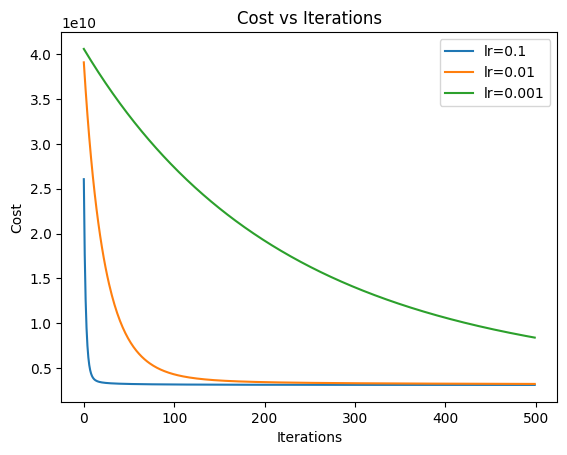

In [ ]:
learning_rates = [0.1, 0.01, 0.001]

results = {}

for lr in learning_rates:
    
    w = np.zeros(n_features)
    b = 0
    
    w, b, cost_history = gradient_descent(X_train, y_train, w, b, lr, 500)
    
    results[lr] = cost_history
    
    plt.plot(cost_history, label=f"lr={lr}")

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.legend()
plt.show()

In [ ]:
def predict(X, w, b):
    return np.dot(X, w) + b

In [ ]:
y_pred = predict(X_test, w, b)
MAE = np.mean(np.abs(y_test - y_pred))
MSE = np.mean((y_test - y_pred) ** 2)
RMSE = np.sqrt(MSE)
R2 = 1 - (np.sum((y_test - y_pred) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))

print("MAE:", MAE)
print("MSE:", MSE)
print("RMSE:", RMSE)
print("R2 Score:", R2)

MAE: 113294.73525325891
MSE: 17678571448.902145
RMSE: 132960.78914064154
R2 Score: -0.7723854244042427


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = LinearRegression()

model.fit(X_train, y_train)

y_pred_sklearn = model.predict(X_test)

print("Sklearn Results")

print("MAE:", mean_absolute_error(y_test, y_pred_sklearn))
print("MSE:", mean_squared_error(y_test, y_pred_sklearn))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_sklearn)))
print("R2:", r2_score(y_test, y_pred_sklearn))

Sklearn Results
MAE: 42741.88721613868
MSE: 3352455828.199866
RMSE: 57900.395751668795
R2: 0.663895702034822


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred_sklearn = model.predict(X_test)

In [ ]:
print("Sklearn MAE:", mean_absolute_error(y_test, y_pred_sklearn))
print("Sklearn MSE:", mean_squared_error(y_test, y_pred_sklearn))
print("Sklearn RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_sklearn)))
print("Sklearn R2:", r2_score(y_test, y_pred_sklearn))

Sklearn MAE: 42741.88721613868
Sklearn MSE: 3352455828.199866
Sklearn RMSE: 57900.395751668795
Sklearn R2: 0.663895702034822


In [ ]:
def stochastic_gradient_descent(X, y, lr=0.00001, epochs=50):

    n, m = X.shape
    
    w = np.zeros(m)
    b = 0
    
    for epoch in range(epochs):
        
        for i in range(n):
            
            xi = X[i]
            yi = y[i]
            
            y_pred = np.dot(xi, w) + b
            
            error = yi - y_pred
            
            dw = -2 * xi * error
            db = -2 * error
            
            w = w - lr * dw
            b = b - lr * db
            
    return w, b

In [ ]:
w_sgd, b_sgd = stochastic_gradient_descent(X_train, y_train)

y_pred_sgd = np.dot(X_test, w_sgd) + b_sgd

mse_sgd = np.mean((y_test - y_pred_sgd)**2)

print("SGD MSE:", mse_sgd)

SGD MSE: 3607831253.973277


In [ ]:
MAE



np.float64(113294.73525325891)

In [ ]:
MSE

np.float64(17678571448.902145)

In [ ]:
RMSE

np.float64(132960.78914064154)

In [ ]:
r2_score

<function sklearn.metrics._regression.r2_score(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average', force_finite=True)>